### Домашнее задание 1 - 15 баллов

1. Загрузите набор данных lenta-ru-news с помощью библиотеки Corus для задачи классификации текстов по топикам (пригодятся атрибуты title, text, topic)
2. Подготовьте данные к обучению: - **3 балла**
    - Выделите репрезентативную часть датасета размеро 100_000 текстов
    - Предобработайте данные: реализуйте оптимальную, на ваш взгляд, предобработку текстов (нормализация, очистка, стемминг/лемматизация и т.п.) и таргета. Постарайтесь добиться приемлемой скорости обработки за счет оптимизаций.
    - Кратко опишите пайплайн предобработки, на котором остановились, и почему.
    - Разделите датасет на обучающую, валидационную и тестовую выборки со стратификацией в пропорции 60/20/20. В качестве целевой переменной используйте атрибут `topic`
3. Замерьте базовое качество с любым dummy-бейзлайном - **1 балл**
4. Обучите модель `sklearn.linear_model.LogisticRegression` с двумя вариантами векторизации: **3 балла**
  - `sklearn.feature_extraction.text.CountVectorizer`
  - `sklearn.feature_extraction.text.TfidfVectorizer`
5. Попробуйте улучшить качество, подобрав оптимальные гиперпараметры трансформаций и модели на кросс-валидации **2 балла**
6. Оцените качество лучшего пайплайна на отложенной выборке, проведите анализ ошибок модели, сделайте выводы - **2 балла**


**Общее**

- Принимаемые решения обоснованы (почему выбрана определенная архитектура/гиперпараметр/оптимизатор/преобразование и т.п.), по ходу работы присутствуют комментарии и выводы - **3 балла**
- Обеспечена воспроизводимость решения: зафиксированы random_state, ноутбук воспроизводится от начала до конца без ошибок - **1 балл**

### План работы:
1. Загрузить датасет
2. Подготовить репрезентативную выборку на 100_000 текстов
3. Выполнить предобработку текста
4. Разделить данные на train / valid / test в пропорции 60 / 20 / 20 со стратификацией
5. Оценить dummy baseline
6. Обучить `LogisticRegression` с `CountVectorizer`
7. Обучить `LogisticRegression` с `TfidfVectorizer`
8. Подобрать гиперпараметры лучшего пайплайна на кросс-валидации
9. Оценить качество на test и провести анализ ошибок

In [1]:
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from corus import load_lenta

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
RANDOM_STATE = 42
# фиксирую random_state = 42, чтобы разбиение данных, сэмплирование и обучение моделей были воспроизводимыми

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [3]:
DATA_PATH = Path("lenta-ru-news.csv.gz")
print(DATA_PATH)

if not DATA_PATH.exists():
    !wget -O lenta-ru-news.csv.gz https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

lenta-ru-news.csv.gz


In [4]:
assert DATA_PATH.exists(), "Не удалось скачать lenta-ru-news.csv.gz"
DATA_PATH

PosixPath('lenta-ru-news.csv.gz')

In [5]:
records = load_lenta(str(DATA_PATH))
first_record = next(records)
first_record

LentaRecord(
    url='https://lenta.ru/news/2018/12/14/cancer/',
    title='Названы регионы России с\xa0самой высокой смертностью от\xa0рака',
    text='Вице-премьер по социальным вопросам Татьяна Голикова рассказала, в каких регионах России зафиксирована наиболее высокая смертность от рака, сообщает РИА Новости. По словам Голиковой, чаще всего онкологические заболевания становились причиной смерти в Псковской, Тверской, Тульской и Орловской областях, а также в Севастополе. Вице-премьер напомнила, что главные факторы смертности в России — рак и болезни системы кровообращения. В начале года стало известно, что смертность от онкологических заболеваний среди россиян снизилась впервые за три года. По данным Росстата, в 2017 году от рака умерли 289 тысяч человек. Это на 3,5 процента меньше, чем годом ранее.',
    topic='Россия',
    tags='Общество',
    date=None
)

In [6]:
rows = []

for rec in tqdm(load_lenta(str(DATA_PATH)), desc="Loading lenta"):
    rows.append({
        "title": rec.title,
        "text": rec.text,
        "topic": rec.topic
    })

df = pd.DataFrame(rows)
df.head()

Loading lenta: 0it [00:00, ?it/s]

,title,text,topic
0,Названы регионы России с самой высокой смертно...,Вице-премьер по социальным вопросам Татьяна Го...,Россия
1,Австрия не представила доказательств вины росс...,Австрийские правоохранительные органы не предс...,Спорт
2,Обнаружено самое счастливое место на планете,Сотрудники социальной сети Instagram проанализ...,Путешествия
3,В США раскрыли сумму расходов на расследование...,С начала расследования российского вмешательст...,Мир
4,Хакеры рассказали о планах Великобритании зами...,Хакерская группировка Anonymous опубликовала н...,Мир


In [7]:
print(df.shape)
df.info()

# Далее использую только три поля: title, text, topic

(739351, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 739351 entries, 0 to 739350
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   title   739351 non-null  object
 1   text    739351 non-null  object
 2   topic   739351 non-null  object
dtypes: object(3)
memory usage: 16.9+ MB


In [8]:
df.isna().sum() # пропуски

title    0
text     0
topic    0
dtype: int64

In [9]:
# Уникальные топики
display(df["topic"].value_counts().head(24))
# Насколько сбалансированы темы
display(df["topic"].value_counts().describe())

topic
Россия               160519
Мир                  136680
Экономика             79538
Спорт                 64421
Культура              53803
Бывший СССР           53402
Наука и техника       53136
Интернет и СМИ        44675
Из жизни              27611
Дом                   21734
Силовые структуры     19596
Ценности               7766
Бизнес                 7399
Путешествия            6408
69-я параллель         1268
Крым                    666
Культпросвет            340
                        203
Легпром                 114
Библиотека               65
Оружие                    3
ЧМ-2014                   2
МедНовости                1
Сочи                      1
Name: count, dtype: int64

count        24.000000
mean      30806.291667
std       43981.406926
min           1.000000
25%         180.750000
50%        7582.500000
75%       53202.500000
max      160519.000000
Name: count, dtype: float64

In [10]:
df = df.copy()

df["title"] = df["title"].astype(str)
df["text"] = df["text"].astype(str)
df["topic"] = df["topic"].astype(str)

In [11]:
# Убираем темы состоящие только из пробелов
df["topic"] = df["topic"].str.strip()

# Удаляем пустые темы
df = df[df["topic"] != ""].copy()

df.shape

(739148, 3)

In [12]:
MIN_CLASS_SIZE = 100
# чищу малопредставленные классы, чтобы стратифицированное разбиение стало стабильнее,метрики по классам стали более интерпретируемыми, модель не тратила ресурсы на темы по которым слишком мало примеров для надежного обучения

topic_counts = df["topic"].value_counts()

valid_topics = topic_counts[topic_counts >= MIN_CLASS_SIZE].index
df = df[df["topic"].isin(valid_topics)].copy()

df.shape

(739076, 3)

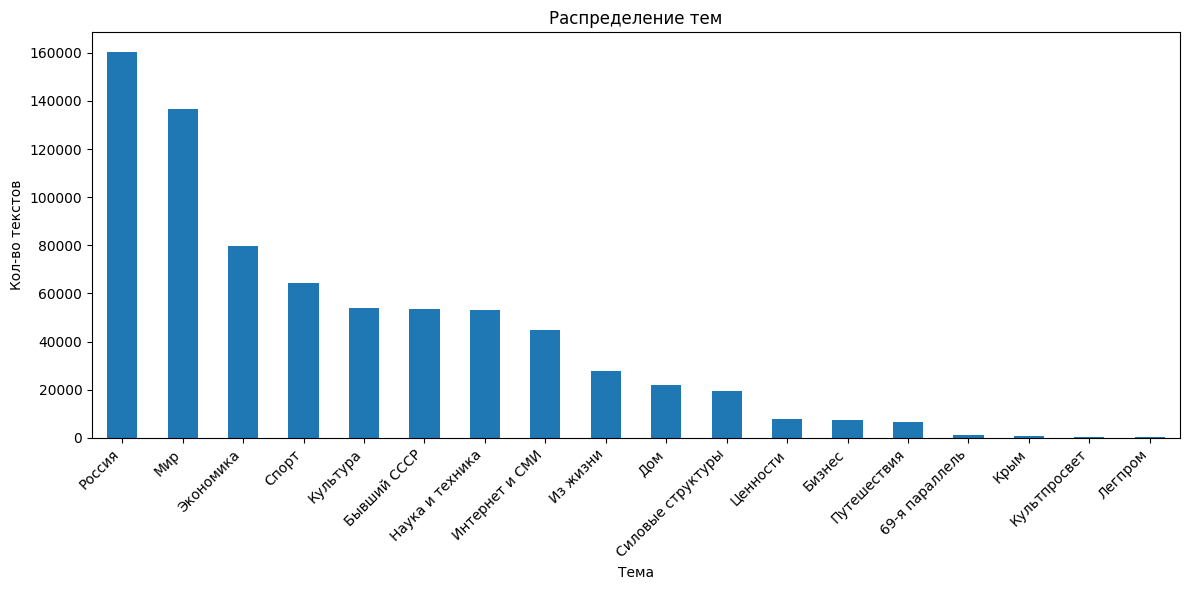

In [13]:
plt.figure(figsize=(12, 6))
df["topic"].value_counts().head(20).plot(kind="bar")
plt.title("Распределение тем")
plt.xlabel("Тема")
plt.ylabel("Кол-во текстов")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
# Сэмплируем 100к
N_SAMPLES = 100_000

if len(df) > N_SAMPLES:
    df_sample, _ = train_test_split(
        df,
        train_size=N_SAMPLES,
        stratify=df["topic"],
        random_state=RANDOM_STATE
    )
else:
    df_sample = df.copy()

df_sample = df_sample.reset_index(drop=True)

print(df_sample.shape)
print((df_sample["topic"].value_counts(normalize=True) * 100).round(2))

(100000, 3)
topic
Россия               21.72
Мир                  18.49
Экономика            10.76
Спорт                 8.72
Культура              7.28
Бывший СССР           7.22
Наука и техника       7.19
Интернет и СМИ        6.04
Из жизни              3.74
Дом                   2.94
Силовые структуры     2.65
Ценности              1.05
Бизнес                1.00
Путешествия           0.87
69-я параллель        0.17
Крым                  0.09
Культпросвет          0.05
Легпром               0.02
Name: proportion, dtype: float64


In [15]:
# предобработка текста без лемматизации и стемминга, так как для этой задачи она скорее не дает гарантированого прироста => не используем в угоду скорости предобработки
# обьединяю title + text, привел к lowercase, почистил url'ы и пробелы
URL_RE = re.compile(r"https?://\S+|www\.\S+")
NON_WORD_RE = re.compile(r"[^0-9a-zа-яё\- ]+", flags=re.IGNORECASE)
MULTISPACE_RE = re.compile(r"\s+")

def normalize_text(title: str, text: str) -> str:
    s = f"{title} {text}".lower()
    s = s.replace("\xa0", " ")
    s = URL_RE.sub(" ", s)
    s = NON_WORD_RE.sub(" ", s)
    s = MULTISPACE_RE.sub(" ", s).strip()
    return s

tqdm.pandas()
df_sample["clean_text"] = df_sample.progress_apply(
    lambda row: normalize_text(row["title"], row["text"]),
    axis=1
)

df_sample = df_sample[df_sample["clean_text"] != ""].reset_index(drop=True)
df_sample[["title", "topic", "clean_text"]].head()

  0%|          | 0/100000 [00:00<?, ?it/s]

,title,topic,clean_text
0,Подросток стрелял по людям из пневматического ...,Россия,подросток стрелял по людям из пневматического ...
1,Япония запустила самую маленькую ракету-носитель,Наука и техника,япония запустила самую маленькую ракету-носите...
2,Основатель «Пятерочки» продаст отель-усадьбу в...,Дом,основатель пятерочки продаст отель-усадьбу в к...
3,"На Украине опубликуют ""черный список антисемитов""",Бывший СССР,на украине опубликуют черный список антисемито...
4,Россия приступила к разработке аппарата для ис...,Наука и техника,россия приступила к разработке аппарата для ис...


In [16]:
X = df_sample["clean_text"]
y = df_sample["topic"]

print(X.shape, y.shape)

(100000,) (100000,)


In [17]:
# разбиение 60 / 20 / 20
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_STATE
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_valid.shape, X_test.shape)

(60000,) (20000,) (20000,)


## Dummy baseline

In [18]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(np.zeros((len(X_train), 1)), y_train)

valid_pred_dummy = dummy.predict(np.zeros((len(X_valid), 1)))

dummy_acc = accuracy_score(y_valid, valid_pred_dummy)
dummy_f1 = f1_score(y_valid, valid_pred_dummy, average="macro")

print("Dummy accuracy:", round(dummy_acc, 4))
print("Dummy macro_f1:", round(dummy_f1, 4))

Dummy accuracy: 0.2172
Dummy macro_f1: 0.0198


## Кастомные наследованные классы с прогрессом

In [19]:
class TqdmCountVectorizer(CountVectorizer):
    def _wrap_with_tqdm(self, raw_documents, desc):
        total = len(raw_documents) if hasattr(raw_documents, "__len__") else None
        for doc in tqdm(raw_documents, total=total, desc=desc):
            yield doc

    def fit_transform(self, raw_documents, y=None):
        return super().fit_transform(self._wrap_with_tqdm(raw_documents, "CountVectorizer fit_transform"), y)

    def transform(self, raw_documents):
        return super().transform(self._wrap_with_tqdm(raw_documents, "CountVectorizer transform"))

class TqdmTfidfVectorizer(TfidfVectorizer):
    def _wrap_with_tqdm(self, raw_documents, desc):
        total = len(raw_documents) if hasattr(raw_documents, "__len__") else None
        for doc in tqdm(raw_documents, total=total, desc=desc):
            yield doc

    def fit_transform(self, raw_documents, y=None):
        return super().fit_transform(self._wrap_with_tqdm(raw_documents, "TfidfVectorizer fit_transform"), y)

    def transform(self, raw_documents):
        return super().transform(self._wrap_with_tqdm(raw_documents, "TfidfVectorizer transform"))        

## LogReg + CountVectorizer

In [20]:
count_pipe = Pipeline([
    ("vectorizer", TqdmCountVectorizer(
        ngram_range=(1, 1),
        min_df=5,
        max_df=0.9,
        max_features=100_000
    )),
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    ))
])

count_pipe.fit(X_train, y_train)

CountVectorizer fit_transform:   0%|          | 0/60000 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


Epoch 1, change: 1
Epoch 2, change: 0.19204673
Epoch 3, change: 0.1091492
Epoch 4, change: 0.074882304
Epoch 5, change: 0.062174167
Epoch 6, change: 0.051308831
Epoch 7, change: 0.040237769
Epoch 8, change: 0.036137471
Epoch 9, change: 0.03338282
Epoch 10, change: 0.031163
Epoch 11, change: 0.02781444
Epoch 12, change: 0.025342803
Epoch 13, change: 0.023609678
Epoch 14, change: 0.021501655
Epoch 15, change: 0.020323414
Epoch 16, change: 0.018547735
Epoch 17, change: 0.017491516
Epoch 18, change: 0.016177001
Epoch 19, change: 0.015122817
Epoch 20, change: 0.014463145
Epoch 21, change: 0.013433778
Epoch 22, change: 0.012932308
Epoch 23, change: 0.012578755
Epoch 24, change: 0.012265099
Epoch 25, change: 0.011866671
Epoch 26, change: 0.011581727
Epoch 27, change: 0.011337021
Epoch 28, change: 0.011037572
Epoch 29, change: 0.01070724
Epoch 30, change: 0.01050848
Epoch 31, change: 0.01026897
Epoch 32, change: 0.010020416
Epoch 33, change: 0.0098566441
Epoch 34, change: 0.0096422556
Epoch 35

/home/mlcore/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,steps,"[('vectorizer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


## LogReg + TfidfVectorizer

In [21]:
tfidf_pipe = Pipeline([
    ("vectorizer", TqdmTfidfVectorizer(
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.9,
        max_features=150_000,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    ))
])

tfidf_pipe.fit(X_train, y_train)

TfidfVectorizer fit_transform:   0%|          | 0/60000 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


Epoch 1, change: 1
Epoch 2, change: 0.17717101
Epoch 3, change: 0.064740055
Epoch 4, change: 0.03960643
Epoch 5, change: 0.024773237
Epoch 6, change: 0.015894352
Epoch 7, change: 0.017567706
Epoch 8, change: 0.01381503
Epoch 9, change: 0.0094226293
Epoch 10, change: 0.010552057
Epoch 11, change: 0.010014928
Epoch 12, change: 0.0027120405
Epoch 13, change: 0.0020112536
Epoch 14, change: 0.0009104063
Epoch 15, change: 0.00067076846
Epoch 16, change: 0.00031207478
Epoch 17, change: 0.00032573834
Epoch 18, change: 0.00023168318
Epoch 19, change: 0.00055938772
Epoch 20, change: 0.00022116035
convergence after 21 epochs took 21 seconds


,steps,"[('vectorizer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [22]:
valid_pred_count = count_pipe.predict(X_valid)
valid_pred_tfidf = tfidf_pipe.predict(X_valid)

count_acc = accuracy_score(y_valid, valid_pred_count)
count_f1 = f1_score(y_valid, valid_pred_count, average="macro")

tfidf_acc = accuracy_score(y_valid, valid_pred_tfidf)
tfidf_f1 = f1_score(y_valid, valid_pred_tfidf, average="macro")

print("Count accuracy:", round(count_acc, 4))
print("Count macro_f1:", round(count_f1, 4))
print()
print("TFIDF accuracy:", round(tfidf_acc, 4))
print("TFIDF macro_f1:", round(tfidf_f1, 4))

CountVectorizer transform:   0%|          | 0/20000 [00:00<?, ?it/s]

TfidfVectorizer transform:   0%|          | 0/20000 [00:00<?, ?it/s]

Count accuracy: 0.8153
Count macro_f1: 0.6186

TFIDF accuracy: 0.807
TFIDF macro_f1: 0.5523


In [23]:
results_valid = pd.DataFrame([
    ["Dummy", dummy_acc, dummy_f1],
    ["LogReg + CountVectorizer", count_acc, count_f1],
    ["LogReg + TfidfVectorizer", tfidf_acc, tfidf_f1],
], columns=["model", "accuracy", "macro_f1"])

results_valid.sort_values("macro_f1", ascending=False)

,model,accuracy,macro_f1
1,LogReg + CountVectorizer,0.81525,0.618555
2,LogReg + TfidfVectorizer,0.80700,0.552319
0,Dummy,0.21720,0.019827


In [24]:
# LogReg + CountVectorizer не сошелся, а tfidf вариант сошелся быстро, но дал результат хуже -> дальше тюним CountVectorizer вариант

## Подбор гиперпараметров

In [25]:
base_pipe = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=500,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    ))
])

param_grid = {
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "vectorizer__min_df": [3, 5, 10],
    "vectorizer__max_df": [0.8, 0.9, 1.0],
    "vectorizer__max_features": [100_000, 150_000],
    "clf__C": [0.5, 1.0, 2.0]
}

grid = GridSearchCV(
    estimator=base_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=3
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


Epoch 1, change: 1
Epoch 1, change: 1
Epoch 2, change: 0.19151702
Epoch 2, change: 0.2002754


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


Epoch 3, change: 0.10660646
Epoch 3, change: 0.11758577
Epoch 1, change: 1
Epoch 4, change: 0.074951719
Epoch 2, change: 0.17811748
Epoch 4, change: 0.081809064
Epoch 5, change: 0.059220383
Epoch 3, change: 0.10618588
Epoch 5, change: 0.067585207


...

/home/mlcore/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 3/3] END clf__C=2.0, vectorizer__max_df=1.0, vectorizer__max_features=150000, vectorizer__min_df=10, vectorizer__ngram_range=(1, 2);, score=0.621 total time= 7.7min


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


Epoch 1, change: 1
Epoch 2, change: 0.19250184
Epoch 3, change: 0.10980003
Epoch 4, change: 0.075921199
Epoch 5, change: 0.062863835
Epoch 6, change: 0.051936406
Epoch 7, change: 0.04223543
Epoch 8, change: 0.037375131
Epoch 9, change: 0.032379317
Epoch 10, change: 0.030242057
Epoch 11, change: 0.027188781
Epoch 12, change: 0.024889196
Epoch 13, change: 0.023359567
Epoch 14, change: 0.021346271
Epoch 15, change: 0.020222227
Epoch 16, change: 0.018565382
Epoch 17, change: 0.017533691
Epoch 18, change: 0.016353678
Epoch 19, change: 0.015340728
Epoch 20, change: 0.01471252
Epoch 21, change: 0.013732719
Epoch 22, change: 0.013129517
Epoch 23, change: 0.012298336
Epoch 24, change: 0.011679542
Epoch 25, change: 0.011119351
Epoch 26, change: 0.010571484
Epoch 27, change: 0.010075868
Epoch 28, change: 0.0097134819
Epoch 29, change: 0.0091805516
Epoch 30, change: 0.008828061
Epoch 31, change: 0.0085051114
Epoch 32, change: 0.0083871919
Epoch 33, change: 0.0082502283
Epoch 34, change: 0.00792149

/home/mlcore/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [39]:
print("Best CV score:", grid.best_score_)
print("Best params:", grid.best_params_)
# модели оказались полезны биграммы, умеренное отсечение слишком частых слов и чуть более слабая регуляризация

Best CV score: 0.616122448291963
Best params: {'clf__C': 2.0, 'vectorizer__max_df': 0.9, 'vectorizer__max_features': 100000, 'vectorizer__min_df': 3, 'vectorizer__ngram_range': (1, 2)}


In [26]:
best_model = grid.best_estimator_

valid_pred_best = best_model.predict(X_valid)

best_valid_acc = accuracy_score(y_valid, valid_pred_best)
best_valid_f1 = f1_score(y_valid, valid_pred_best, average="macro")

print("Best valid accuracy:", round(best_valid_acc, 4))
print("Best valid macro_f1:", round(best_valid_f1, 4))

Best valid accuracy: 0.8202
Best valid macro_f1: 0.6344


In [27]:
X_train_full = pd.concat([X_train, X_valid], axis=0)
y_train_full = pd.concat([y_train, y_valid], axis=0)

In [28]:
best_model.fit(X_train_full, y_train_full)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


Epoch 1, change: 1
Epoch 2, change: 0.18945314
Epoch 3, change: 0.10622223
Epoch 4, change: 0.074870434
Epoch 5, change: 0.059269377
Epoch 6, change: 0.048921586
Epoch 7, change: 0.041929038
Epoch 8, change: 0.037461777
Epoch 9, change: 0.034222466
Epoch 10, change: 0.031020601
Epoch 11, change: 0.028598647
Epoch 12, change: 0.02649506
Epoch 13, change: 0.024504911
Epoch 14, change: 0.02316366
Epoch 15, change: 0.021778688
Epoch 16, change: 0.01990896
Epoch 17, change: 0.019168149
Epoch 18, change: 0.017647373
Epoch 19, change: 0.016864389
Epoch 20, change: 0.015909678
Epoch 21, change: 0.01511916
Epoch 22, change: 0.014588078
Epoch 23, change: 0.013612551
Epoch 24, change: 0.013197419
Epoch 25, change: 0.012426305
Epoch 26, change: 0.011992943
Epoch 27, change: 0.011412612
Epoch 28, change: 0.010844741
Epoch 29, change: 0.0104473
Epoch 30, change: 0.009957962
Epoch 31, change: 0.0098868522
Epoch 32, change: 0.0096007749
Epoch 33, change: 0.0094667105
Epoch 34, change: 0.0094082014
Epo

/home/mlcore/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,steps,"[('vectorizer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [29]:
test_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred, average="macro")

print("Test accuracy:", round(test_acc, 4))
print("Test macro_f1:", round(test_f1, 4))

Test accuracy: 0.8249
Test macro_f1: 0.6565


In [37]:
print(classification_report(y_test, test_pred))

                   precision    recall  f1-score   support

   69-я параллель       0.92      0.32      0.48        34
           Бизнес       0.67      0.55      0.61       200
      Бывший СССР       0.86      0.83      0.85      1445
              Дом       0.87      0.80      0.83       588
         Из жизни       0.68      0.59      0.63       747
   Интернет и СМИ       0.79      0.72      0.75      1209
             Крым       0.50      0.22      0.31        18
     Культпросвет       0.00      0.00      0.00         9
         Культура       0.87      0.88      0.87      1456
          Легпром       0.00      0.00      0.00         3
              Мир       0.80      0.85      0.82      3699
  Наука и техника       0.85      0.84      0.84      1438
      Путешествия       0.81      0.60      0.69       174
           Россия       0.79      0.84      0.82      4344
Силовые структуры       0.71      0.58      0.63       531
            Спорт       0.97      0.96      0.96      1

/home/mlcore/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mlcore/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mlcore/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [31]:
report_df = pd.DataFrame(classification_report(y_test, test_pred, output_dict=True)).T
report_df.sort_values("f1-score").head(15)

/home/mlcore/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mlcore/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mlcore/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,precision,recall,f1-score,support
Культпросвет,0.000000,0.000000,0.000000,9.00000
Легпром,0.000000,0.000000,0.000000,3.00000
Крым,0.500000,0.222222,0.307692,18.00000
69-я параллель,0.916667,0.323529,0.478261,34.00000
Бизнес,0.674847,0.550000,0.606061,200.00000
Из жизни,0.681048,0.591700,0.633238,747.00000
Силовые структуры,0.705069,0.576271,0.634197,531.00000
macro avg,0.713310,0.625765,0.656524,20000.00000
Путешествия,0.813953,0.603448,0.693069,174.00000
Интернет и СМИ,0.787273,0.716294,0.750108,1209.00000


In [32]:
errors = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true": y_test.reset_index(drop=True),
    "pred": pd.Series(test_pred)
})

errors = errors[errors["true"] != errors["pred"]].copy()
errors.head()

,text,true,pred
6,совет директоров роснефти дал рекомендации по ...,Экономика,Бизнес
11,вывезенная из россии картина малевича возвраща...,Культура,Россия
24,опубликовано видео задержания администратора г...,Интернет и СМИ,Силовые структуры
25,пассажиры самолета москва-бангкок устроили пья...,Из жизни,Россия
29,сикх судится с полицией нью-йорка за право нос...,Из жизни,Мир


In [33]:
error_pairs = (
    errors.groupby(["true", "pred"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

error_pairs.head(20)

,true,pred,count
0,Россия,Мир,291
1,Мир,Россия,270
2,Силовые структуры,Россия,141
3,Из жизни,Мир,138
4,Экономика,Россия,122
5,Россия,Экономика,95
6,Бывший СССР,Россия,92
7,Интернет и СМИ,Россия,92
8,Бывший СССР,Мир,73
9,Россия,Бывший СССР,72


In [34]:
top_true = error_pairs.iloc[0]["true"]
top_pred = error_pairs.iloc[0]["pred"]

examples = errors[
    (errors["true"] == top_true) & (errors["pred"] == top_pred)
].head(5)

examples[["true", "pred", "text"]]

,true,pred,text
122,Россия,Мир,анна политковская посмертно номинирована на пр...
226,Россия,Мир,военно-морской атташе россии в японии покинул ...
264,Россия,Мир,11 человек обвинили в контрабанде водки по тру...
319,Россия,Мир,пакистанская полиция установила личности трех ...
370,Россия,Мир,генштаб признал ядерную угрозу со стороны иран...


### Вывод по анализу ошибок

Лучше всего модель распознает крупные и тематически более однородные рубрики, такие как `Спорт`, `Культура`, `Экономика`, `Бывший СССР` и `Наука и техника`.
Наиболее сложными для модели оказались редкие классы (`Культпросвет`, `Легпром`, `Крым`, `69-я параллель`), что объясняется очень малым числом примеров.

## Вывод

Лучший пайплайн показал на тестовой выборке:
- `accuracy = 0.8249`
- `macro_f1 = 0.6565`

По итогам классификации видно, что модель хорошо распознает крупные и тематически более однородные классы. Наиболее высокие значения `f1-score` получены для классов `Спорт`, `Культура`, `Экономика`, `Бывший СССР`, `Наука и техника`, `Дом`, `Мир` и `Россия`. Это можно объяснить тем, что такие рубрики содержат более устойчивый и специфичный словарь, который легко выделяется линейной моделью.

Сложнее всего модель справляется с редкими классами, такими как `Культпросвет`, `Легпром`, `Крым` и `69-я параллель`. Основная причина — очень маленькое число объектов в этих темах. Даже после фильтрации редких классов для части рубрик в тестовой выборке осталось слишком мало примеров, поэтому модель не успевает выучить для них надежные признаки, а метрики по этим классам оказываются нестабильными.

Анализ наиболее частых ошибок показывает, что модель чаще всего путает тематически близкие рубрики:
- `Россия` и `Мир`
- `Россия` и `Экономика`
- `Бывший СССР` и `Россия`
- `Интернет и СМИ` и `Россия`
- `Бизнес` и `Экономика`

Такая путаница закономерна. Во многих новостях границы между этими темами размыты: политические и экономические события в России могут одновременно относиться к международной повестке, новости про бывшие республики СССР лексически близки к рубрике `Россия`, а новости про бизнес часто содержат экономическую лексику.

Ручной просмотр ошибочно классифицированных примеров подтверждает это наблюдение. В ряде случаев текст содержит смешанный контекст, который подходит сразу к нескольким темам. Например, новости о культуре могут содержать сильную географическую или политическую привязку к России, а новости об интернет-среде могут одновременно включать действия правоохранительных органов или политический контекст. В таких ситуациях даже человеку не всегда очевидно, какая рубрика является наиболее подходящей.

### Выводы по анализу ошибок

1. Модель уверенно работает на крупных и лексически устойчивых темах.
2. Основные ошибки связаны не с шумом модели, а с естественным пересечением тематик в новостных текстах.
3. Самые слабые результаты наблюдаются у редких классов, для которых недостаточно обучающих примеров.
4. Главным ограничением текущего подхода является то, что линейная модель опирается только на частоты слов и словосочетаний и не учитывает более глубокий контекст текста.
5. При этом для задачи базовой классификации новостей выбранный пайплайн показывает хорошее качество и остается быстрым, простым и интерпретируемым.